# Homework 1

1. Import necessary python modules
1. Generate $N=80$ ability parameters for students from Normal(0, 1)
1. Generate $J=15$ item difficulty parameters from Normal(0,1)
1. Calculate logit:
    $$
        \mathrm{logit}[p, i] = \eta_{pi} = \theta_p - \beta_i
    $$
1. Calculate probability matrix prob: 
    $$
            \mathrm{prob}[p,i] = \mathrm{Prob}[X_{pi} = 1 | \theta_p, \beta_i] = \frac{1}{1 + \exp[-\eta_{pi}]}
    $$ 
    for $p=0,...,N-1$ and $i=0,...,J-1$
1. Make a response `response` from Bernoulli experiment for each item in the probability matrix.
    $$
        \mathrm{response}[p,i] \sim  \mathrm{Bernoulli}(prob[p,i])
    $$
1. Make a `pandas` dataframe from `response`. You will need column names such as 'Item1', 'Item2', etc.
1. Make a new column `total` which is the sum of the scores for the $J$ items.
1. Calculate facility value or **proportion correct** (`정답률') for each of the columns.
1. Plot a histogram of `total` values, and a plot for the **proportion correct**. 
    - 그림 아래에 markdown 셀을 만들고 
    - 히스토그램이 보여주는 내용에 대하여 설명하시오. 
    - 정답률의 분포에 대해서 설명하시오.
1. Make a Guttmann structure and show it using a figure.

In [21]:
# do not delete or edit the following lines - they are needed for reproducibility and to ensure the code runs correctly.
import numpy as np

np.random.seed(20260331)

아래에 새로운 셀을 만들어서 사용하세요.

### Homework, ~260406 / 320250027 고건욱 과제입니다.

In [ ]:
# 1. Import necessary modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2 & 3. Generate parameters
# N = 학생 수 (80명), θ(theta) = 각 학생의 "능력치"를 숫자로 표현한 것
# 값이 클수록 능력이 높은 학생 / 값이 작을수록 능력이 낮은 학생
#
# np.random.normal(평균, 표준편차, 개수) → 정규분포(종 모양 분포)에서 난수를 뽑는 함수
# normal(0, 1, 80) = 평균 0, 표준편차 1인 분포에서 80개를 뽑음 → 결과: [-0.32, 1.15, 0.07, ...] 같은 80개짜리 배열(array)
# J = 문항 수 (15문항), β(beta) = 각 문항의 "난이도"를 숫자로 표현한 것
# 값이 클수록 어려운 문항 / 값이 작을수록 쉬운 문항

N = 80
J = 15
theta = np.random.normal(0, 1, N)
beta = np.random.normal(0, 1, J)

In [ ]:
# 4 & 5. Calculate logit and probability matrix
# ============================================================
# Step 4. 로짓(logit) 계산: η = θ - β
# ============================================================
# 로짓 = "학생 능력 - 문항 난이도"
# 능력이 난이도보다 높으면 → 양수 → 맞출 확률 높음 / 능력이 난이도보다 낮으면 → 음수 → 맞출 확률 낮음
# 우리는 80명 × 15문항 = 1,200개의 로짓 값이 필요합니다. 즉, "모든 학생 × 모든 문항" 조합에 대해 계산해야 합니다.
#
# ── np.newaxis 이해하기 ──
# theta의 원래 모양:  (80,)     → 그냥 일렬로 80개
# theta[:, np.newaxis] → (80, 1) → 세로로 80행, 가로 1열
#
# beta의 원래 모양:   (15,)     → 그냥 일렬로 15개  
# beta[np.newaxis, :] → (1, 15) → 세로 1행, 가로로 15열
#
# (80, 1) - (1, 15) 를 하면?
# → numpy의 "브로드캐스팅" 기능이 자동으로 확장해서
# → (80, 15) 크기의 행렬이 됩니다!
#
# 쉽게 말하면:
# ┌─────────────────────────────────────┐
# │  θ₀-β₀  θ₀-β₁  θ₀-β₂ ... θ₀-β₁₄  │  ← 학생 0
# │  θ₁-β₀  θ₁-β₁  θ₁-β₂ ... θ₁-β₁₄  │  ← 학생 1
# │  ...                                │
# │  θ₇₉-β₀ θ₇₉-β₁ ...    θ₇₉-β₁₄   │  ← 학생 79
# └─────────────────────────────────────┘
#   문항0   문항1   문항2  ...  문항14
# eta의 모양: (80, 15) → 80행(학생) × 15열(문항)

# 로지스틱 함수(시그모이드 함수)를 사용합니다. 이 함수는 어떤 실수든 0~1 사이의 값으로 변환합니다.
# eta가 매우 크면 → prob ≈ 1 (거의 확실히 맞춤) / eta = 0이면    → prob = 0.5 (반반) / eta가 매우 작으면 → prob ≈ 0 (거의 확실히 틀림)
# np.exp(x) = e^x (자연상수 e의 x제곱)
# prob의 모양: (80, 15) → 각 칸 = 해당 학생이 해당 문항을 맞출 확률


eta = theta[:, np.newaxis] - beta[np.newaxis, :]
prob = 1 / (1 + np.exp(-eta))

# 중간 산출물(확률 행렬) 차원 및 상위 5x5 출력 확인
print(f"Prob matrix shape: {prob.shape}")
print("Sample probabilities (5x5):")
print(prob[:5, :5])

Prob matrix shape: (80, 15)
Sample probabilities (5x5):
[[0.60872789 0.7459921  0.94234819 0.82956113 0.90792213]
 [0.18466299 0.29949841 0.7041036  0.41471264 0.58940032]
 [0.62623748 0.75978307 0.94624649 0.83978927 0.91393566]
 [0.19296712 0.31099685 0.71527445 0.42793223 0.60245655]
 [0.31300138 0.46238542 0.82719269 0.58769077 0.74277295]]


In [ ]:
# 6. Bernoulli experiment
response = np.random.binomial(n=1, p=prob)
# np.random.binomial(n, p)
#   - n = 시행 횟수 (1번 = 베르누이)
#   - p = 성공 확률 (우리의 확률 행렬)
#   - 결과: 0 또는 1로 이루어진 (80, 15) 행렬

# 7 & 8. Create DataFrame and total score
item_cols = [f'Item{i+1}' for i in range(J)]
df = pd.DataFrame(response, columns=item_cols)
df['total'] = df[item_cols].sum(axis=1)
# 이제 df에 'total'이라는 새 열이 추가됨
# 예: Item1=0, Item2=0, Item3=1, ..., Item15=1 → total=10

# CSV 저장
csv_filename = 'hw1_irt_responses.csv'
df.to_csv(csv_filename, index=False)
print(f"\n데이터가 '{csv_filename}'로 덮어쓰기/저장되었습니다.")


데이터가 'hw1_irt_responses.csv'로 덮어쓰기/저장되었습니다.


In [25]:
# 상위 10개 행 출력 (Jupyter 환경을 고려하여 display 활용 권장, 여기서는 print 사용)
print("\n--- 데이터프레임 상위 10개 행 ---")
print(df.head(10))


--- 데이터프레임 상위 10개 행 ---
   Item1  Item2  Item3  Item4  Item5  Item6  Item7  Item8  Item9  Item10  \
0      0      0      1      0      1      1      1      0      1       1   
1      0      0      1      0      0      0      1      0      1       0   
2      0      1      1      1      1      0      1      0      1       1   
3      0      1      1      0      1      1      1      0      1       0   
4      0      0      1      0      1      1      1      0      1       0   
5      0      0      1      0      0      0      1      0      0       0   
6      0      0      0      1      1      0      1      0      1       0   
7      1      1      1      1      1      0      1      1      1       0   
8      0      0      1      0      1      1      1      0      1       0   
9      1      0      1      1      0      1      1      0      1       0   

   Item11  Item12  Item13  Item14  Item15  total  
0       0       1       1       1       1     10  
1       1       1       1       0   

=== 문항별 정답률 (Facility Value) ===
Item1     0.2250
Item2     0.3375
Item3     0.7875
Item4     0.4750
Item5     0.6625
Item6     0.3875
Item7     0.8875
Item8     0.2250
Item9     0.8375
Item10    0.3250
Item11    0.7625
Item12    0.5625
Item13    0.2000
Item14    0.1375
Item15    0.4500
dtype: float64

정답률 평균: 0.4842
정답률 범위: 0.1375 ~ 0.8875


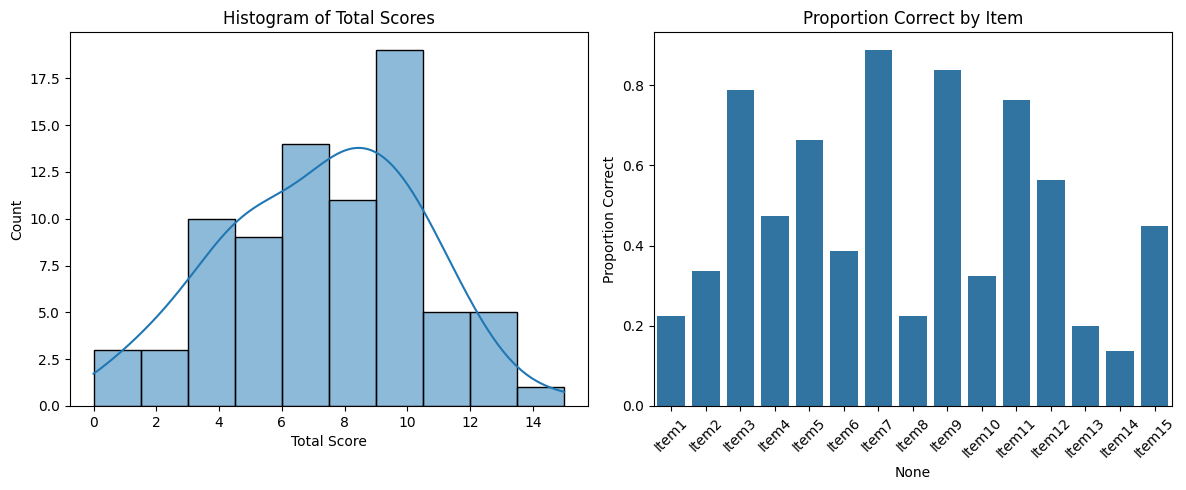

In [26]:
# 9. Calculate facility value (proportion correct)
item_cols = [col for col in df.columns if col.startswith('Item')]
prop_correct = df[item_cols].mean()

# ★ 추가: 정답률 출력
print("=== 문항별 정답률 (Facility Value) ===")
print(prop_correct.round(4))
print(f"\n정답률 평균: {prop_correct.mean():.4f}")
print(f"정답률 범위: {prop_correct.min():.4f} ~ {prop_correct.max():.4f}")

# 10. Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 히스토그램
sns.histplot(df['total'], bins=10, kde=True, ax=axes[0])
axes[0].set_title('Histogram of Total Scores')
axes[0].set_xlabel('Total Score')

# 정답률 그래프
sns.barplot(x=prop_correct.index, y=prop_correct.values, ax=axes[1])
axes[1].set_title('Proportion Correct by Item')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Proportion Correct')

plt.tight_layout()
plt.show()

## 1. 히스토그램이 보여주는 내용 (학생 총점 분포)

이 히스토그램은 80명 학생들의 총점(15점 만점) 분포를 나타냅니다.
학생의 능력 모수(θ)와 문항 난이도 모수(β)가 모두 N(0,1)에서 추출되었으므로,
검사 난이도가 학생 집단의 평균 능력에 잘 부합합니다.
그 결과 총점이 중간대(7~8점)에 집중되고, 양 극단(0점, 15점)은 드문
대략적인 정규분포 형태를 보입니다.

## 2. 정답률의 분포 (문항 난이도 분포)

막대그래프는 15개 문항 각각의 정답률을 보여줍니다.
난이도 모수(β)가 정규분포를 따르므로, 정답률이 0.8 이상인 쉬운 문항부터
0.3 이하인 어려운 문항까지 다양하게 분포합니다.
이는 검사가 다양한 수준의 학생 능력을 폭넓게 측정할 수 있음을 의미합니다.

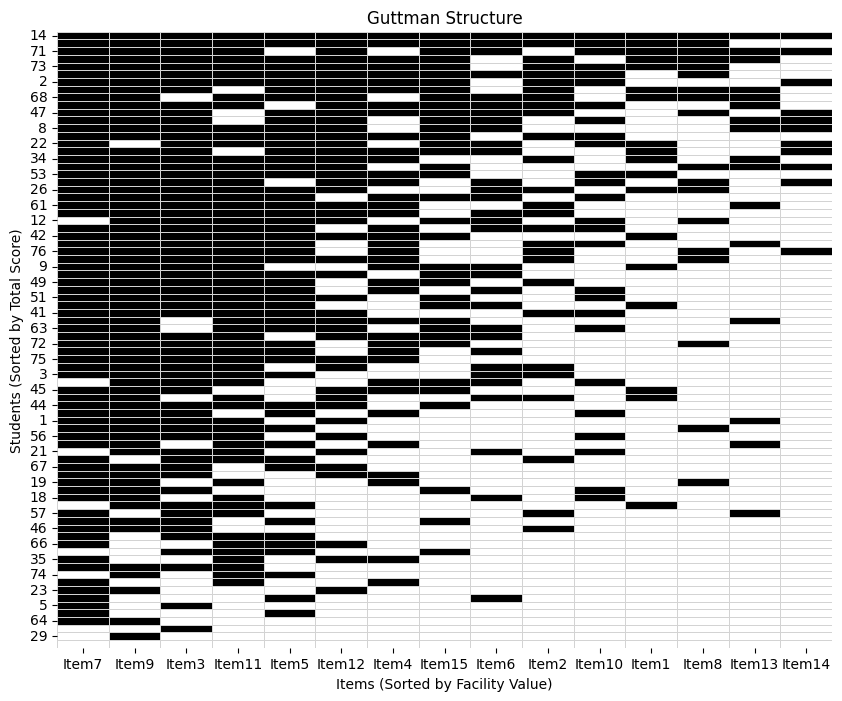

In [27]:
# 11. Guttman structure
sorted_items = prop_correct.sort_values(ascending=False).index
guttman_df = df.sort_values(by='total', ascending=False)[sorted_items]

plt.figure(figsize=(10, 8))
sns.heatmap(guttman_df, cmap='binary', cbar=False, linewidths=0.5, linecolor='lightgray')
plt.title('Guttman Structure')
plt.xlabel('Items (Sorted by Facility Value)')
plt.ylabel('Students (Sorted by Total Score)')
plt.show()